# Partial (online-learning) vs. tuned (full-cohort) model agreement

Hypothesis: the causal-forest model refit on a small, partial population during
the guided-enrollment simulation (`05_online_learning_policy_comparison_exp.ipynb`)
learns the rarer ischaemic-event CATEs poorly, because at small sample sizes it
sees very few ischaemic events (death=81, mi=109, stroke=35 positives out of
4579 patients total). These partial, mid-trial models are exactly what drives
the enrolment/direction decisions in the guided-enrollment mechanism, so their
agreement with the model fit on the whole cohort is worth checking directly.

Method: fit one **partial** model on a subset of patients enrolled partway
through a simulated trial (Angle net-benefit policy, the flagship
guided-enrollment rule, same mechanism as notebook 05 but stripped to just the
enrolment loop -- no re-tuning, no AUTOC/uncertainty diagnostics). Score both
the partial model and the **tuned** model (fit on the full 4579-patient
cohort, `CausalForest_multioutput_tuned.joblib`) on the patients *not*
included in the partial model's training set, so the comparison is genuinely
out-of-sample for the partial model. Scatterplot the two models' CATE
predictions against each other per endpoint and report Pearson/Spearman
correlation -- low agreement on the ischaemic endpoints relative to bleed
would support the hypothesis.

In [24]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import joblib
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

Xn = X.select_dtypes(include=[np.number])                                        # numeric design matrix (nb 06)
T  = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()   # 1=prolonged, 0=shortened
ENDPOINTS = {'bleed': 'cec_bleed_335d', 'death': 'cec_cvdeath_335d',
             'mi': 'cec_mi_335d', 'stroke': 'cec_stroke_335d'}
ONLINE_TARGETS = list(ENDPOINTS)                            # ['bleed','death','mi','stroke'] -> partial model's CATE column order
Yv = y[[ENDPOINTS[k] for k in ONLINE_TARGETS]].to_numpy()
BLEED_IDX = ONLINE_TARGETS.index('bleed')                   # seed tuning targets the bleeding endpoint (nb 06 convention)
N = len(T)
ISCH_WEIGHTS = {'death': 0.2, 'mi': 0.4, 'stroke': 0.4}      # ISCH_WEIGHTS convention (online_learning_utils.weighted_isch)
print('patients:', N, '| prolonged:', int(T.sum()), 'shortened:', int((T == 0).sum()))

patients: 4579 | prolonged: 2284 shortened: 2295


In [25]:
CF_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'Meta-learning', 'causal_forest'))
sys.path.insert(0, CF_DIR)
SCRIPTS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'scripts'))
sys.path.insert(0, SCRIPTS_DIR)

from casual_multioutput_pipeline import CausalMultiOutputPipeline, CF_MODEL_PRESETS
from online_learning_utils import (fit_cate, conflict_from_model, weighted_isch, tune_on_seed,
                                    DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS)
from online_learning_policies import score_angle_net_benefit

## Build the partial model

Whole-pool ranking loop, same mechanism as notebook 05's `run_enrollment` with
the Angle net-benefit (+45°) policy, stripped to only what this comparison
needs: draw a seed cohort, hyper-tune the forest on it ONCE (`tune_on_seed`,
the same Optuna search nb05's `seed_fit_tune`/`tune_seed` runs), then
repeatedly score the remaining pool with the *current* model, enrol the top
batch, refit with the seed-tuned config -- no re-tuning past the seed cohort.
`run_enrollment`'s own docstring warns against that: past the seed, the
enrolled population is one the mechanism itself chose, so re-tuning there
would optimise against a self-selected sample rather than the population.
No exploration bonus (`c=0`), no AUTOC/uncertainty bookkeeping. Stops once
`N_PARTIAL` patients are enrolled.

In [26]:
def sample_batch(score, pool, batch_size):
    """Greedy top-k selection by score (temperature=0 case of nb05's sample_batch)."""
    score = np.asarray(score, dtype=float)
    pool = np.asarray(pool)
    n = min(batch_size, len(pool))
    return pool[np.argsort(score)[::-1][:n]]


def fit_partial_model(n_seed, n_partial, batch_size, seed, n_trials=20, tune_cv=3,
                       n_jobs=32, lgbm_n_jobs=16, verbose=True):
    """Angle-net-benefit enrolment loop, returns (model, enrolled_idx) once
    `n_partial` patients are enrolled -- the 'model partway through the
    adaptive trial' this notebook compares against the tuned full model.

    Hyperparameters are tuned ONCE on the seed cohort (`tune_on_seed`, same
    Optuna search nb05's `seed_fit_tune` runs) and reused for every refit --
    never re-tuned on the enrolled cohort itself, which by construction is no
    longer a random draw from the population once the policy starts picking.
    `n_trials=0` skips the search and falls back to DEFAULT_CF_PARAMS."""
    rng = np.random.default_rng(seed)
    order = rng.permutation(N)
    enrolled = list(order[:n_seed])

    in_pool = np.ones(N, dtype=bool)
    in_pool[enrolled] = False
    pool = np.flatnonzero(in_pool)

    zero_unc = pd.DataFrame({'uncertainty': np.zeros(N)})

    if n_trials:
        cf_params, nuisance_params, study = tune_on_seed(
            enrolled, Xn, Yv, T, CausalMultiOutputPipeline, CF_MODEL_PRESETS,
            BLEED_IDX, n_trials=n_trials, cv=tune_cv, seed=seed,
            optuna_n_jobs=1, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        if verbose:
            print(f'  seed hyper-tuned on n={len(enrolled)}: best CV score = {study.best_value:+.4f}')
    else:
        cf_params, nuisance_params = DEFAULT_CF_PARAMS, DEFAULT_NUISANCE_PARAMS

    model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params,
                      nuisance_params, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
    if verbose:
        print(f'  seed fit: n={len(enrolled)}')

    while len(pool) and len(enrolled) < n_partial:
        frame = conflict_from_model(model, Xn, ENDPOINTS, ISCH_WEIGHTS, ONLINE_TARGETS)
        score = score_angle_net_benefit(frame, zero_unc, pool, ISCH_WEIGHTS, c=0.0)
        batch = sample_batch(score, pool, batch_size)

        enrolled.extend(batch.tolist())
        in_pool[batch] = False
        pool = np.flatnonzero(in_pool)

        model = fit_cate(enrolled, Xn, Yv, T, CausalMultiOutputPipeline, cf_params,
                          nuisance_params, n_jobs=n_jobs, lgbm_n_jobs=lgbm_n_jobs)
        if verbose:
            print(f'  refit: n={len(enrolled)}')

    return model, enrolled

In [27]:
N_SEED, BATCH_SIZE, N_PARTIAL = 1000, 100, 3500
N_TRIALS = 20   # seed-cohort Optuna trials, same value nb05's run_all uses for seed_fit_tune

print(f'Fitting the partial (online-learning) model: seed={N_SEED}, stop at n={N_PARTIAL}, seed tuning trials={N_TRIALS} ...')
partial_model, enrolled = fit_partial_model(N_SEED, N_PARTIAL, BATCH_SIZE, SEED, n_trials=N_TRIALS)
held_out = np.setdiff1d(np.arange(N), enrolled)
print(f'partial model trained on {len(enrolled)} patients | held out (unseen by partial model): {len(held_out)}')

Fitting the partial (online-learning) model: seed=1000, stop at n=3500, seed tuning trials=20 ...
  seed hyper-tuned on n=1000: best CV score = -0.0000
  seed fit: n=1000
  refit: n=1100
  refit: n=1200
  refit: n=1300
  refit: n=1400
  refit: n=1500
  refit: n=1600
  refit: n=1700
  refit: n=1800
  refit: n=1900
  refit: n=2000
  refit: n=2100
  refit: n=2200
  refit: n=2300
  refit: n=2400
  refit: n=2500
  refit: n=2600
  refit: n=2700
  refit: n=2800
  refit: n=2900
  refit: n=3000
  refit: n=3100
  refit: n=3200
  refit: n=3300
  refit: n=3400
  refit: n=3500
partial model trained on 3500 patients | held out (unseen by partial model): 1079


## Load the tuned model (fit on the full cohort)

In [28]:
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'Meta-learning', 'models'))
TUNED_MODEL_PATH = os.path.join(MODELS_DIR, 'CausalForest', 'CausalForest_multioutput_tuned.joblib')

tuned_model = joblib.load(TUNED_MODEL_PATH)
print('tuned model loaded:', os.path.basename(TUNED_MODEL_PATH))

tuned model loaded: CausalForest_multioutput_tuned.joblib


## Predict CATE on the held-out patients with both models

Align by endpoint **name**, not column position: the tuned model was fit with
5 endpoints in the order `['barc_235','death','mi','stroke','bleed']`
(`06_causal_forest_cate_estimation.ipynb`), while the partial (online) model
only fits the 4 endpoints in `ONLINE_TARGETS` order (`['bleed','death','mi','stroke']`,
no `barc_235`).

In [31]:
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']   # tuned model's own fit order (nb 06)

X_held = Xn.values[held_out]

partial_cate = partial_model.predict_cate(X_held)
tuned_cate = tuned_model.predict_cate(X_held)

partial_df = pd.DataFrame(partial_cate, columns=ONLINE_TARGETS)              # bleed, death, mi, stroke
tuned_df = pd.DataFrame(tuned_cate, columns=TARGET_LABELS)[ONLINE_TARGETS]   # same 4 endpoints, same order

partial_df['isch'] = weighted_isch({k: partial_df[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
tuned_df['isch'] = weighted_isch({k: tuned_df[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)

print(f'partial model (n={len(enrolled)}) CATE on the held-out patients:')
print(partial_df.describe().round(3))
print()
print(f'tuned model (fit on all {N} patients) CATE on the SAME held-out patients:')
print(tuned_df.describe().round(3))
print()

compare = pd.DataFrame({
    'partial_mean': partial_df.mean(), 'partial_std': partial_df.std(),
    'tuned_mean': tuned_df.mean(), 'tuned_std': tuned_df.std(),
})
print('mean / spread side by side:')
print(compare.round(4))


enrolled_cate = partial_model.predict_cate(Xn.values[enrolled])
tuned_enrolled_cate = tuned_model.predict_cate(Xn.values[enrolled])

enrolled_df = pd.DataFrame(enrolled_cate, columns=ONLINE_TARGETS)              # bleed, death, mi, stroke
tuned_enrolled_df = pd.DataFrame(tuned_enrolled_cate, columns=TARGET_LABELS)[ONLINE_TARGETS]   # same 4 endpoints, same order

enrolled_df['isch'] = weighted_isch({k: enrolled_df[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
tuned_enrolled_df['isch'] = weighted_isch({k: tuned_enrolled_df[k] for k in ISCH_WEIGHTS}, ISCH_WEIGHTS)
print(f'partial model (n={len(enrolled)}) CATE on the enrolled patients:')
print(enrolled_df.describe().round(3))
print()
print(f'tuned model (fit on all {N} patients) CATE on the enrolled patients:')
print(tuned_enrolled_df.describe().round(3))

partial model (n=3500) CATE on the held-out patients:
          bleed     death        mi    stroke      isch
count  1079.000  1079.000  1079.000  1079.000  1079.000
mean      0.044     0.000    -0.006     0.003    -0.001
std       0.005     0.002     0.003     0.003     0.002
min       0.030    -0.006    -0.016    -0.002    -0.007
25%       0.041    -0.001    -0.008     0.001    -0.002
50%       0.044     0.000    -0.006     0.002    -0.001
75%       0.047     0.002    -0.004     0.005     0.000
max       0.057     0.007     0.002     0.017     0.006

tuned model (fit on all 4579 patients) CATE on the SAME held-out patients:
          bleed     death        mi    stroke      isch
count  1079.000  1079.000  1079.000  1079.000  1079.000
mean      0.040     0.002    -0.004     0.004     0.000
std       0.006     0.002     0.003     0.006     0.002
min       0.025    -0.004    -0.013    -0.004    -0.004
25%       0.036     0.001    -0.006    -0.001    -0.001
50%       0.040     0.001    -

## Scatterplot + correlation, per endpoint

x = partial-model CATE, y = tuned-model CATE, both scored on the held-out
patients. Pearson r and Spearman ρ are annotated per panel (Spearman as a
robustness check against skewed CATE distributions for the rarer endpoints).

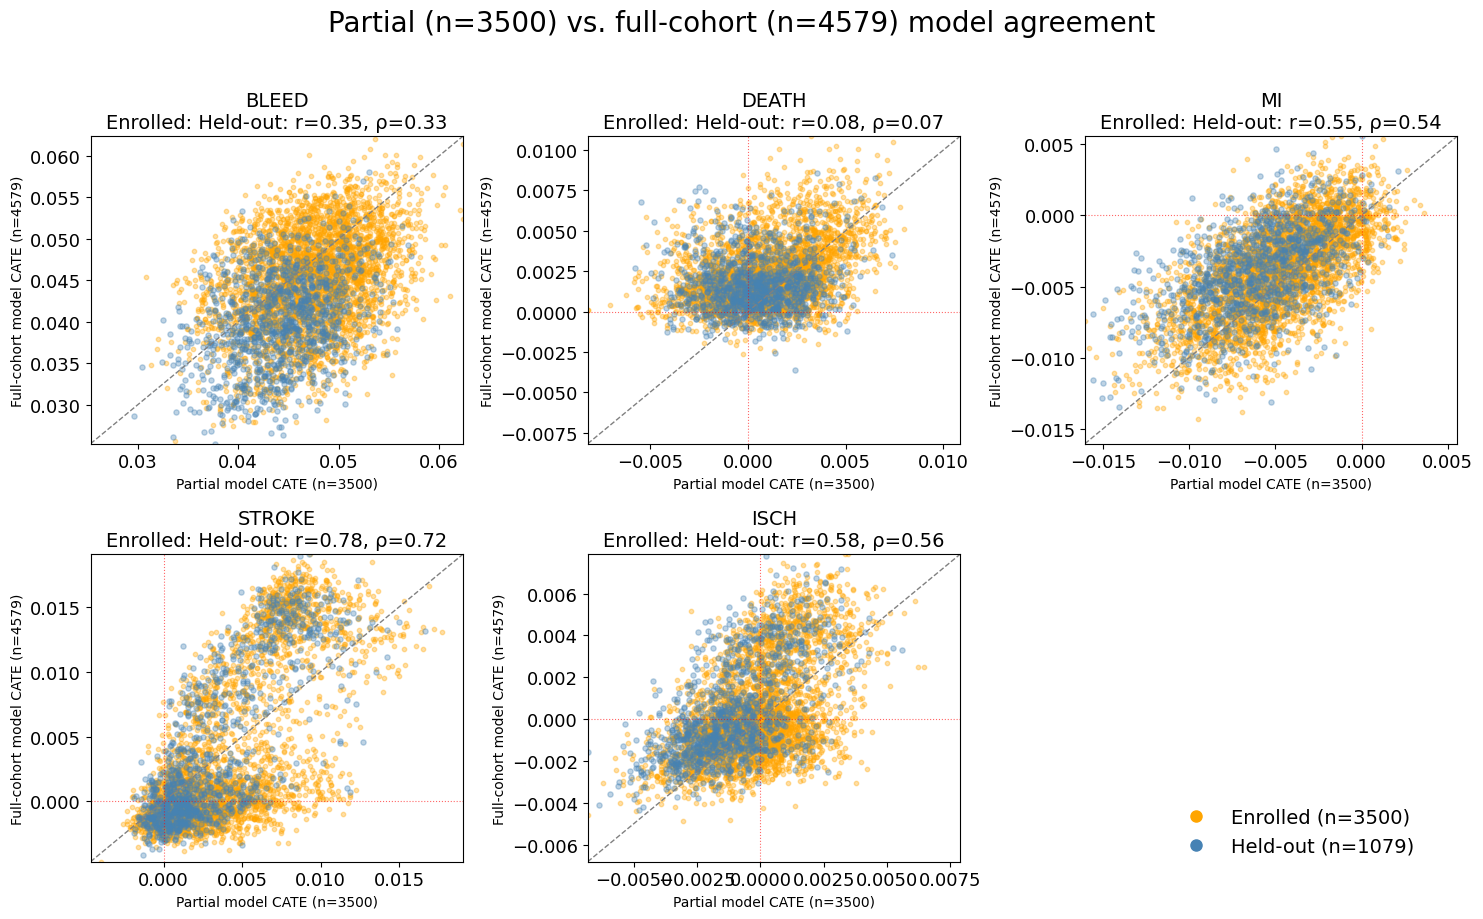

                   pearson_r  spearman_rho     n
endpoint group                                  
bleed    enrolled      0.352         0.335  3500
         held-out      0.352         0.329  1079
death    enrolled      0.377         0.348  3500
         held-out      0.077         0.065  1079
mi       enrolled      0.634         0.640  3500
         held-out      0.552         0.542  1079
stroke   enrolled      0.693         0.639  3500
         held-out      0.775         0.725  1079
isch     enrolled      0.501         0.468  3500
         held-out      0.576         0.557  1079


In [47]:
from matplotlib.lines import Line2D

PANELS = ['bleed', 'death', 'mi', 'stroke', 'isch']

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 10,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.titlesize": 20, "legend.fontsize": 14
})

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
rows = []

for ax, ep in zip(axes, PANELS):
    xe, ye = enrolled_df[ep].to_numpy(), tuned_enrolled_df[ep].to_numpy()
    xh, yh = partial_df[ep].to_numpy(), tuned_df[ep].to_numpy()

    re, _ = pearsonr(xe, ye)
    rhoe, _ = spearmanr(xe, ye)
    rh, _ = pearsonr(xh, yh)
    rhoh, _ = spearmanr(xh, yh)

    rows += [
        dict(endpoint=ep, group='enrolled', pearson_r=re, spearman_rho=rhoe, n=len(xe)),
        dict(endpoint=ep, group='held-out', pearson_r=rh, spearman_rho=rhoh, n=len(xh))
    ]

    ax.scatter(xe, ye, s=10, alpha=.35, color='orange')
    ax.scatter(xh, yh, s=14, alpha=.35, color='steelblue')

    vals = np.concatenate([xe, ye, xh, yh])
    lo, hi = vals.min(), vals.max()
    ax.plot([lo, hi], [lo, hi], '--', color='grey', lw=1)
    ax.axhline(0, color='red', ls=':', lw=.8, alpha=.6)
    ax.axvline(0, color='red', ls=':', lw=.8, alpha=.6)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_xlabel(f'Partial model CATE (n={len(enrolled)})')
    ax.set_ylabel(f'Full-cohort model CATE (n={N})')
    ax.set_title(
        f'{ep.upper()}\n'
        f'Enrolled: Held-out: r={rh:.2f}, ρ={rhoh:.2f}'
    )

axes[-1].set_visible(False)

orange_dot = Line2D([0], [0], marker='o', ls='None', color='orange',
                    markersize=8, label=f'Enrolled (n={len(enrolled_df)})')
blue_dot = Line2D([0], [0], marker='o', ls='None', color='steelblue',
                  markersize=8, label=f'Held-out (n={len(partial_df)})')

fig.legend(handles=[orange_dot, blue_dot], loc='lower right',
           bbox_to_anchor=(.96, .06), frameon=False)
fig.suptitle(f'Partial (n={len(enrolled)}) vs. full-cohort (n={N}) model agreement', y=1.02)
fig.tight_layout()

FIG_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'figures'))
os.makedirs(FIG_DIR, exist_ok=True)
fig.savefig(os.path.join(FIG_DIR, 'partial_vs_tuned_agreement.png'),
            dpi=150, bbox_inches='tight')
plt.show()

summary = pd.DataFrame(rows).set_index(['endpoint', 'group'])
print(summary.round(3))